#**[프로젝트] 서울 전월세 가격 변동 요인 분석 - 금리와 지하철 접근성을 중심으로**
- [서울시 부동산 전월세가 정보](https://data.seoul.go.kr/dataList/OA-21276/S/1/datasetView.do) : 서울 부동산 정보광장에서 제공하는 전월세가 정보입니다. 자치구, 법정동, 건물명, 임대건물명, 전월세구분, 보증금, 임대료, 계약년도 등의 전월세 정보를 제공합니다.

# 3. 데이터 분석
전처리가 완료된 데이터를 바탕으로 금리와 월세간의 상관관계를 분석합니다.

- H1.정부대출금리 변동은 단위면적당 월세 변동에 영향을 미칠 것이다.

- H2.정부대출금리 변동에 따른 월세 임대료 변화는 서울의 자치구에 따라 차이가 있을 것이다.

In [1]:
!pip install koreanize-matplotlib geopy tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 50.1 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from tqdm import tqdm
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns

In [4]:
df = pd.read_csv("/content/main_processed_data.csv", encoding = "utf-8-sig")

/tmp/ipykernel_607/3687470153.py:1: DtypeWarning: Columns (18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/main_processed_data.csv", encoding = "utf-8-sig")


In [ ]:
df.columns

Index(['접수년도', '자치구코드', '자치구명', '법정동코드', '법정동명', '지번구분코드', '지번구분', '본번', '부번',
       '층', '계약일', '전월세구분', '임대면적', '보증금(만원)', '임대료(만원)', '건물명', '건축년도',
       '건물용도', '계약기간', '신규계약구분', '갱신청구권사용', '종전보증금', '종전임대료', 'address',
       '월세_㎡당', '년월', '정부대출금금리'],
      dtype='object')

### 3-1. 기본 데이터 확인
변수 분포와 결측치 확인

In [ ]:
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.unicode_minus"] = False

sns.set_style("whitegrid")

print(f"전체 거래 건수: {len(df):,}건")
print(f"분석 기간: {df['년월'].min()} ~ {df['년월'].max()}")

print("\n주요 변수 기술통계")
print(
    df[
        [
            "임대료(만원)",
            "보증금(만원)",
            "임대면적",
            "월세_㎡당",
            "정부대출금금리"
        ]
    ].describe().round(2)
)

전체 거래 건수: 1,468,362건
분석 기간: 2016-01 ~ 2025-12

주요 변수 기술통계
          임대료(만원)     보증금(만원)        임대면적       월세_㎡당     정부대출금금리
count  1468362.00  1468362.00  1468362.00  1468362.00  1468362.00
mean        74.29    12758.76       48.13        1.78        2.21
std         73.89    19265.72       29.65        1.27        1.03
min          1.00        0.00       10.00        0.01        0.60
25%         35.00     2000.00       24.49        0.75        1.39
50%         57.00     5000.00       40.17        1.53        1.87
75%         88.00    15600.00       59.99        2.54        3.30
max       2300.00   810000.00      445.12        8.57        3.71


In [ ]:
# 결측치 확인
check_cols = [
    "년월",
    "월세_㎡당",
    "임대료(만원)",
    "보증금(만원)",
    "정부대출금금리",
    "자치구명"
]

missing = df[check_cols].isna().sum()

print(missing)

년월         0
월세_㎡당      0
임대료(만원)    0
보증금(만원)    0
정부대출금금리    0
자치구명       0
dtype: int64


월별 거래량 추이

In [10]:
# 월별 변수 생성

df["년월"] = (
    df["계약일"].astype(str).str[:4] + "-" +
    df["계약일"].astype(str).str[4:6]
)

monthly_stats = (
    df
    .groupby("년월")
    .agg(
        거래건수=("임대료(만원)", "size"),

        월세_평균=("임대료(만원)", "mean"),
        월세_중앙값=("임대료(만원)", "median"),

        제곱미터당월세_평균=("월세_㎡당", "mean"),
        제곱미터당월세_중앙값=("월세_㎡당", "median"),

        보증금_평균=("보증금(만원)", "mean"),
        보증금_중앙값=("보증금(만원)", "median"),

        면적_평균=("임대면적", "mean"),
        면적_중앙값=("임대면적", "median"),

        정부대출금금리=("정부대출금금리", "first")
    )
    .reset_index()
    .sort_values("년월")
)

print("\n===== 월별 데이터 =====")
print(monthly_stats.head())

print(f"\n월별 데이터 행 수: {len(monthly_stats):,}개월")
print(f"최종 원자료 행 수: {len(df):,}건")


===== 월별 데이터 =====
        년월   거래건수      월세_평균  월세_중앙값  제곱미터당월세_평균  제곱미터당월세_중앙값        보증금_평균  \
0  2016-01  10509  61.858883    50.0    1.482718     1.302837  12391.922543   
1  2016-02   9933  59.338870    50.0    1.416964     1.207729  12148.038256   
2  2016-03   9657  59.806047    50.0    1.278889     1.097602  12198.284768   
3  2016-04   8067  59.876906    50.0    1.283370     1.124438  12288.030495   
4  2016-05   7406  62.820146    50.0    1.326360     1.161624  12672.538077   

   보증금_중앙값      면적_평균  면적_중앙값  정부대출금금리  
0   5000.0  52.370247   47.28    1.664  
1   5000.0  52.837093   49.57    1.664  
2   5000.0  56.085007   52.27    1.664  
3   5000.0  55.621965   51.29    1.602  
4   5000.0  56.351843   51.86    1.602  

월별 데이터 행 수: 120개월
최종 원자료 행 수: 1,468,362건


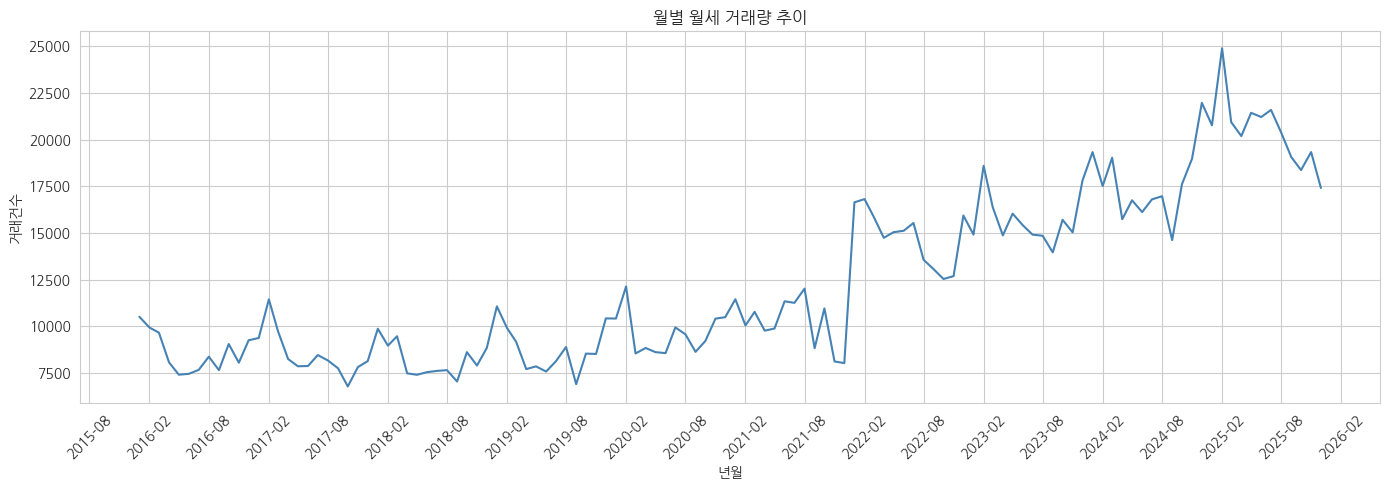

In [ ]:
import matplotlib.dates as mdates

plot_df = monthly_stats.copy()

plot_df["년월_날짜"] = pd.to_datetime(plot_df["년월"])

plt.figure(figsize=(14, 5))

sns.lineplot(
    data=plot_df,
    x="년월_날짜",
    y="거래건수",
    color="steelblue"
)

plt.title("월별 월세 거래량 추이")
plt.xlabel("년월")
plt.ylabel("거래건수")

# 6개월마다 x축 표시
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%Y-%m")
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

단위면적당 월세의 월별 추이

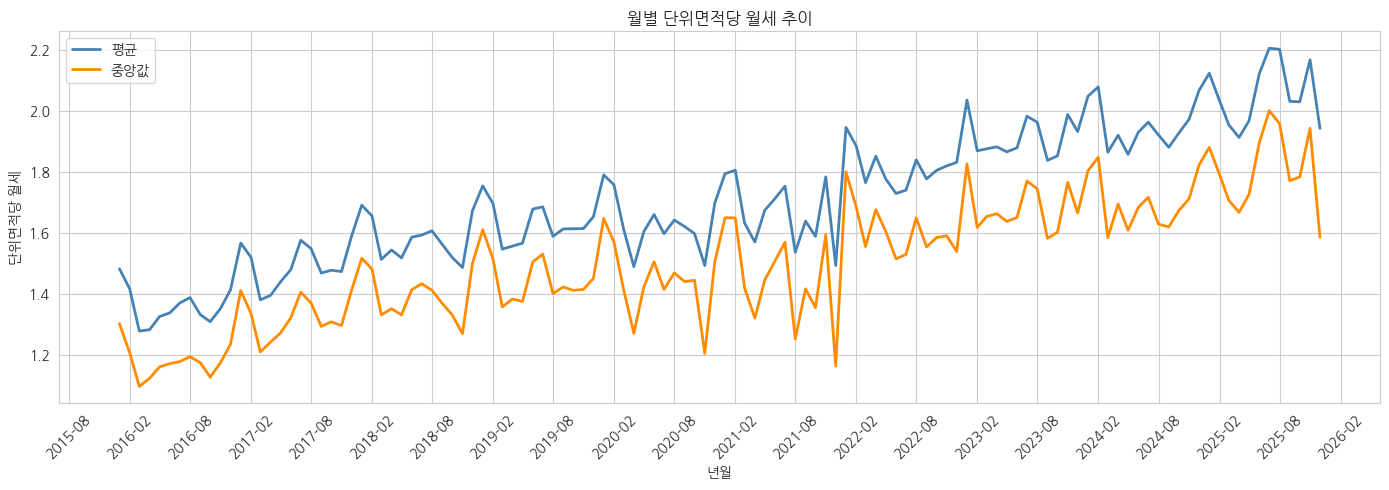

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["년월_날짜"],
    plot_df["제곱미터당월세_평균"],
    label="평균",
    color="steelblue",
    linewidth=2
)

plt.plot(
    plot_df["년월_날짜"],
    plot_df["제곱미터당월세_중앙값"],
    label="중앙값",
    color="darkorange",
    linewidth=2
)

plt.title("월별 단위면적당 월세 추이")
plt.xlabel("년월")
plt.ylabel("단위면적당 월세")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

월별 보증금 추이

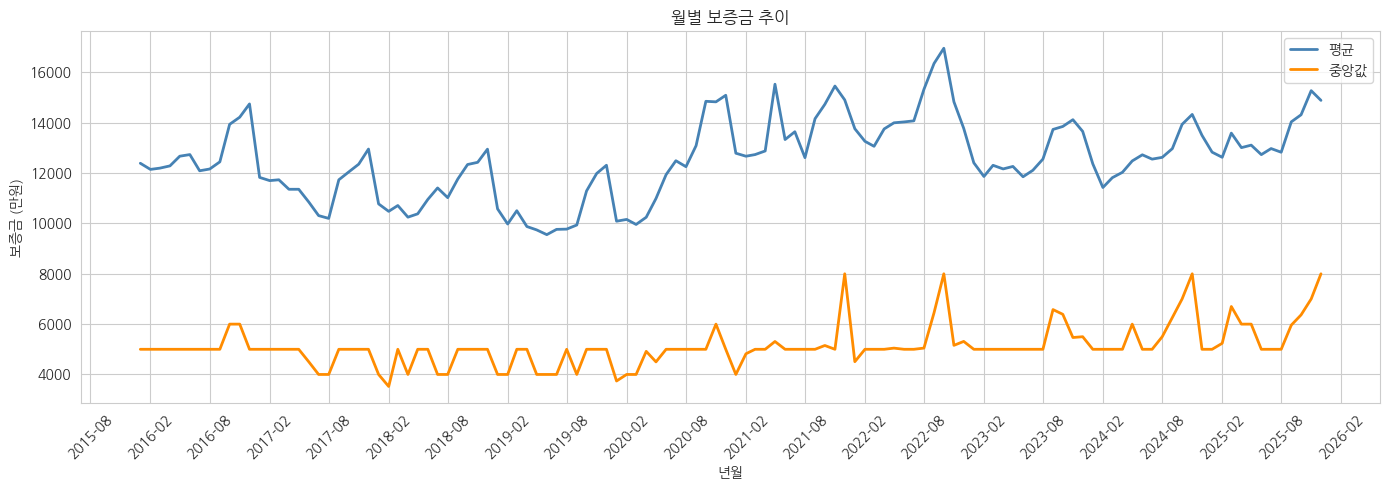

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    plot_df["년월_날짜"],
    plot_df["보증금_평균"],
    label="평균",
    color="steelblue",
    linewidth=2
)

plt.plot(
    plot_df["년월_날짜"],
    plot_df["보증금_중앙값"],
    label="중앙값",
    color="darkorange",
    linewidth=2
)

plt.title("월별 보증금 추이")
plt.xlabel("년월")
plt.ylabel("보증금 (만원)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

월별 정부대출금리 추이

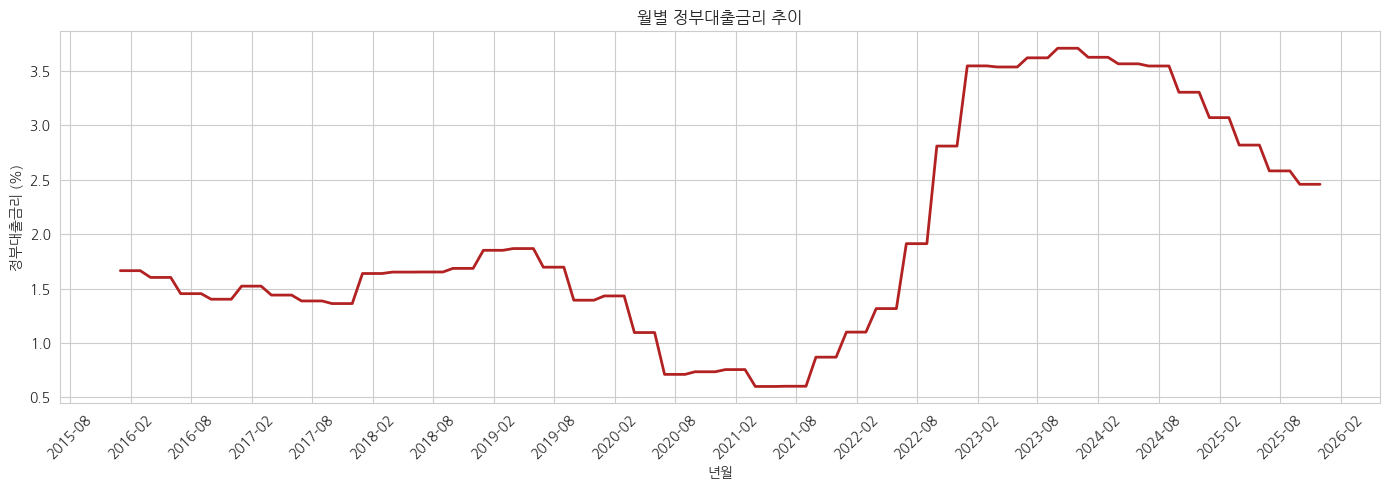

In [ ]:
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=plot_df,
    x="년월_날짜",
    y="정부대출금금리",
    color="firebrick",
    linewidth=2
)

plt.title("월별 정부대출금리 추이")
plt.xlabel("년월")
plt.ylabel("정부대출금리 (%)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. 가설검정

정부대출금리와 단위면적당 월세 추이

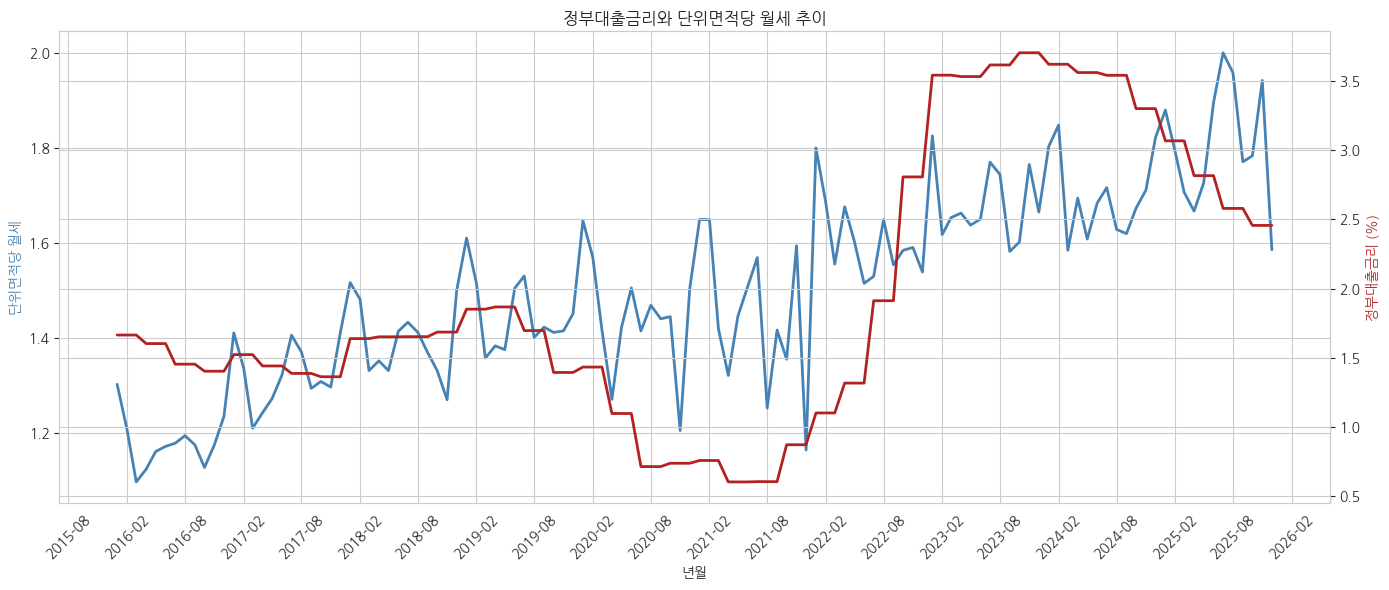

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    plot_df["년월_날짜"],
    plot_df["제곱미터당월세_중앙값"],
    color="steelblue",
    linewidth=2,
    label="단위면적당 월세"
)

ax1.set_xlabel("년월")
ax1.set_ylabel(
    "단위면적당 월세",
    color="steelblue"
)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["년월_날짜"],
    plot_df["정부대출금금리"],
    color="firebrick",
    linewidth=2,
    label="정부대출금리"
)

ax2.set_ylabel(
    "정부대출금리 (%)",
    color="firebrick"
)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax1.tick_params(axis="x", rotation=45)

plt.title("정부대출금리와 단위면적당 월세 추이")

plt.tight_layout()
plt.show()

정부대출금리와 보증금 추이

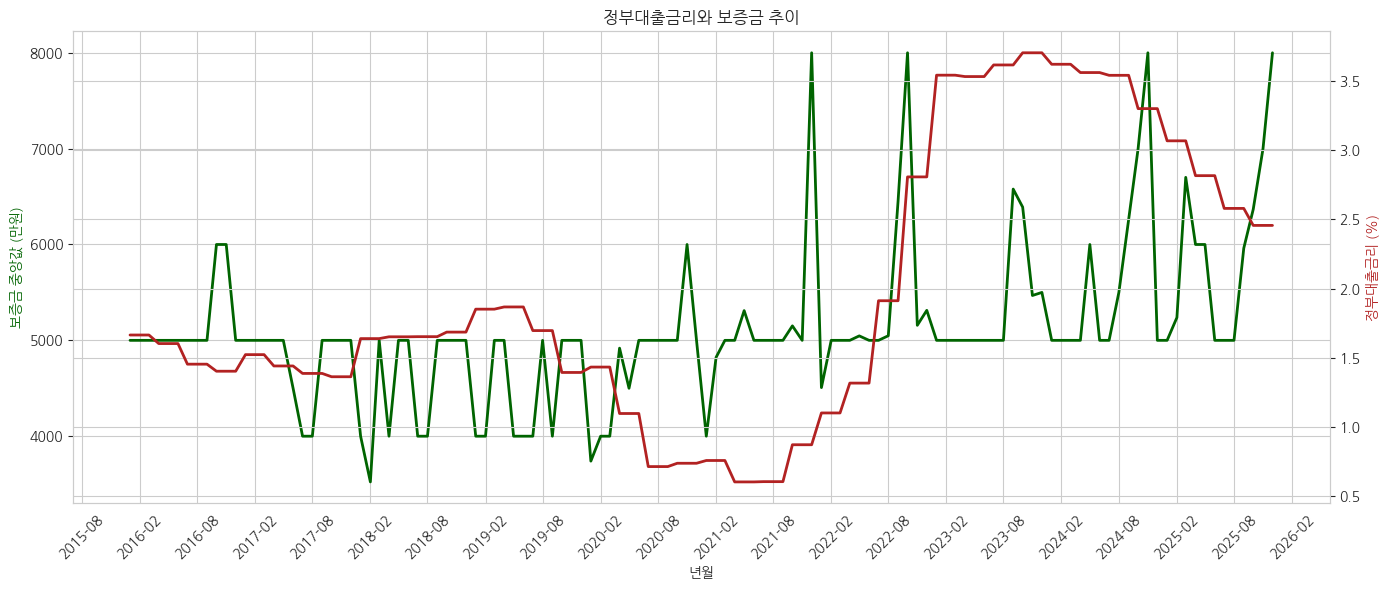

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    plot_df["년월_날짜"],
    plot_df["보증금_중앙값"],
    color="darkgreen",
    linewidth=2,
    label="보증금"
)

ax1.set_xlabel("년월")
ax1.set_ylabel(
    "보증금 중앙값 (만원)",
    color="darkgreen"
)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["년월_날짜"],
    plot_df["정부대출금금리"],
    color="firebrick",
    linewidth=2,
    label="정부대출금리"
)

ax2.set_ylabel(
    "정부대출금리 (%)",
    color="firebrick"
)

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax1.tick_params(axis="x", rotation=45)

plt.title("정부대출금리와 보증금 추이")

plt.tight_layout()
plt.show()

연도별 단위면적당 월세 분포

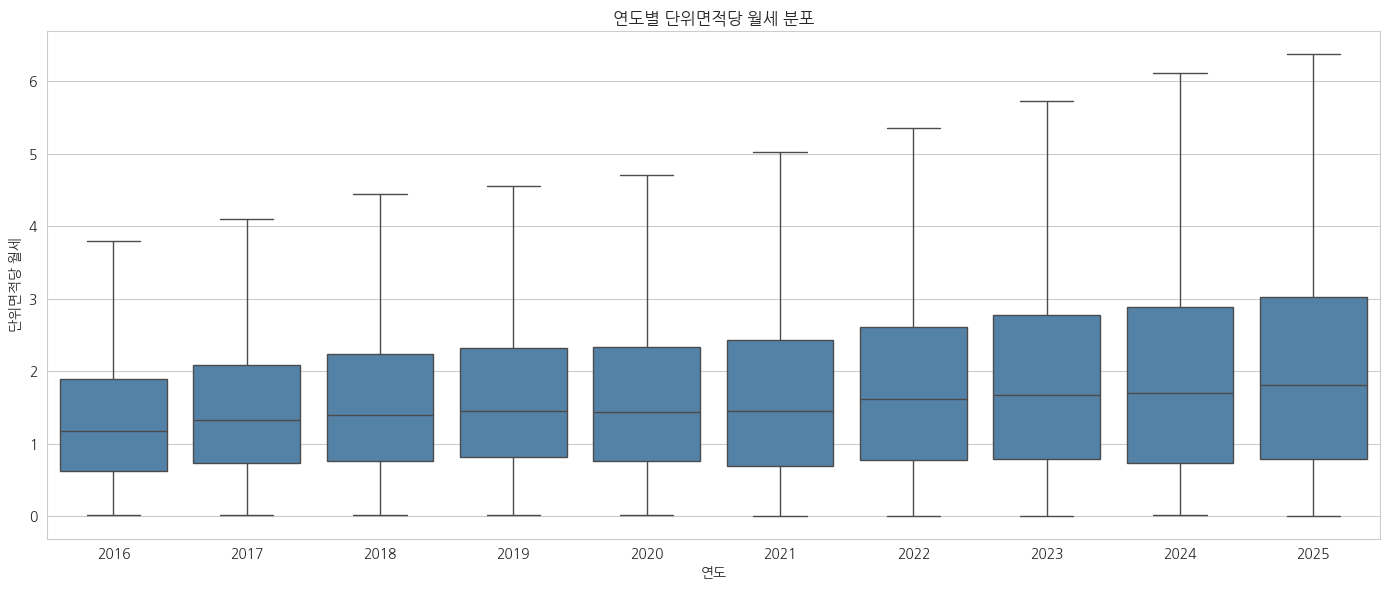

In [ ]:
df["연도"] = df["년월"].str[:4]

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df,
    x="연도",
    y="월세_㎡당",
    showfliers=False,
    color="steelblue"
)

plt.title("연도별 단위면적당 월세 분포")
plt.xlabel("연도")
plt.ylabel("단위면적당 월세")

plt.tight_layout()
plt.show()

자치구별 단위면적당 월세

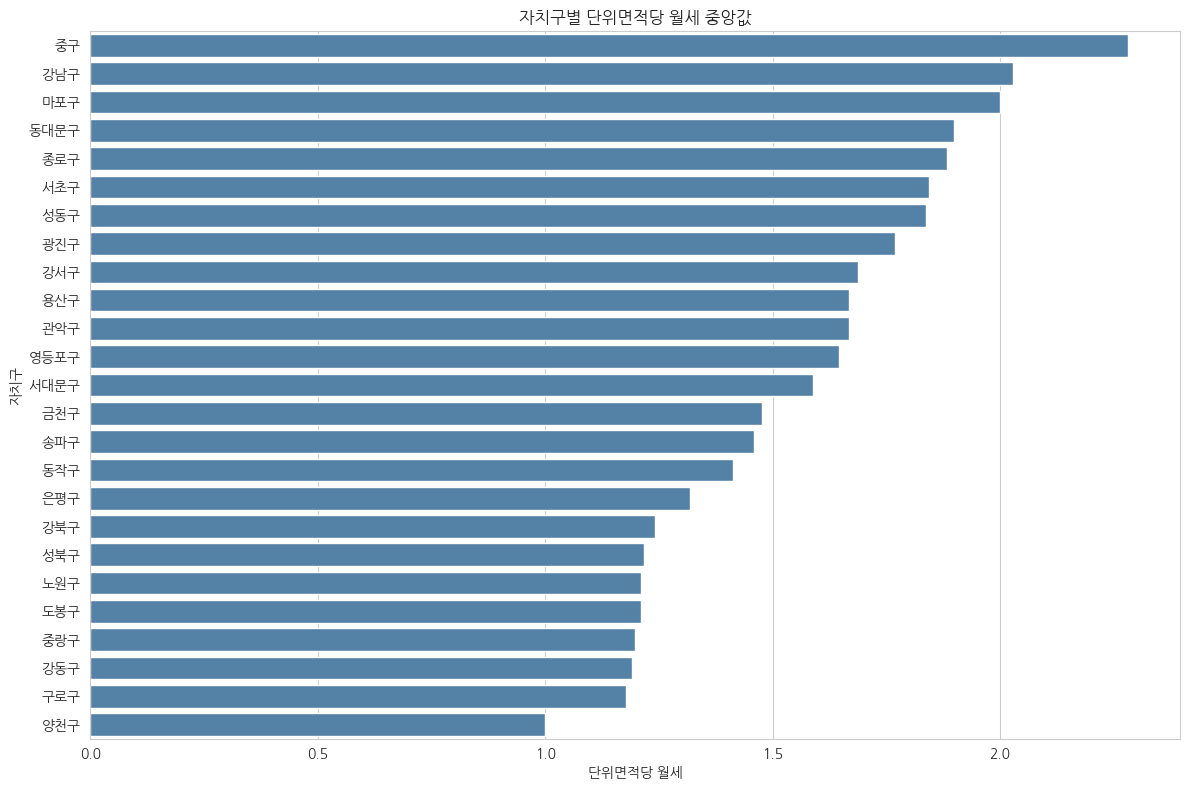

In [ ]:
district_stats = (
    df.groupby("자치구명")
    .agg(
        거래건수=("월세_㎡당", "size"),
        월세_평균=("월세_㎡당", "mean"),
        월세_중앙값=("월세_㎡당", "median")
    )
    .reset_index()
    .sort_values("월세_중앙값", ascending=False)
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=district_stats,
    y="자치구명",
    x="월세_중앙값",
    color="steelblue"
)

plt.title("자치구별 단위면적당 월세 중앙값")
plt.xlabel("단위면적당 월세")
plt.ylabel("자치구")

plt.tight_layout()
plt.show()

금리 변화와 월세 변화

In [ ]:
plot_df["금리변화"] = plot_df["정부대출금금리"].diff()
plot_df["월세변화"] = plot_df["제곱미터당월세_중앙값"].diff()
plot_df["보증금변화"] = plot_df["보증금_중앙값"].diff()

eda_monthly = plot_df.dropna(
    subset=["금리변화", "월세변화", "보증금변화"]
).copy()

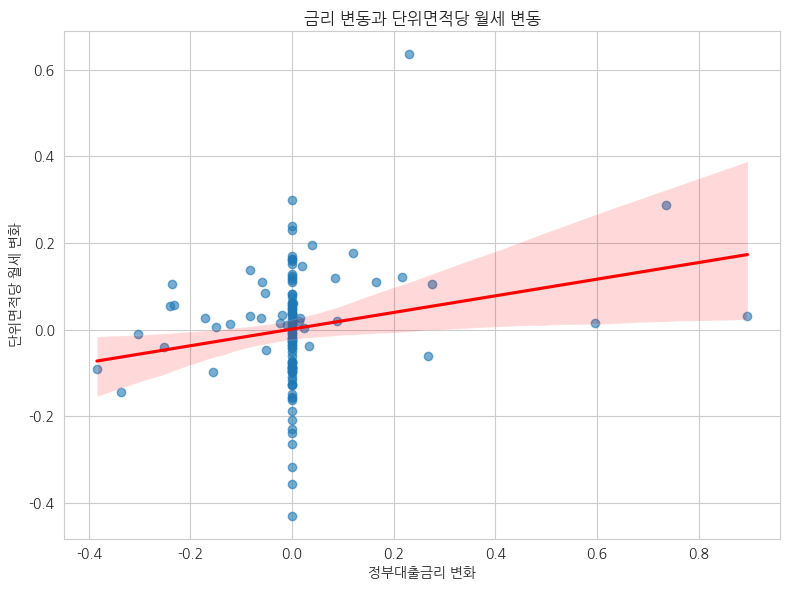

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=eda_monthly,
    x="금리변화",
    y="월세변화",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("금리 변동과 단위면적당 월세 변동")
plt.xlabel("정부대출금리 변화")
plt.ylabel("단위면적당 월세 변화")

plt.tight_layout()
plt.show()

EDA 결과, 정부대출금리의 전월 대비 변동과 단위면적당 월세의 전월 대비 변동 사이에는 양(+)의 관계가 나타났다.

 금리 상승폭이 큰 시점에서 단위면적당 월세 역시 상승하는 관측치가 나타났으며, 회귀선 또한 우상향하는 형태를 보였다.

 다만 일부 금리 급변 시점의 관측치가 전체 관계에 영향을 미칠 가능성이 있으므로, 해당 관계의 통계적 유의성은 회귀분석을 통해 추가적으로 검증할 필요가 있다.

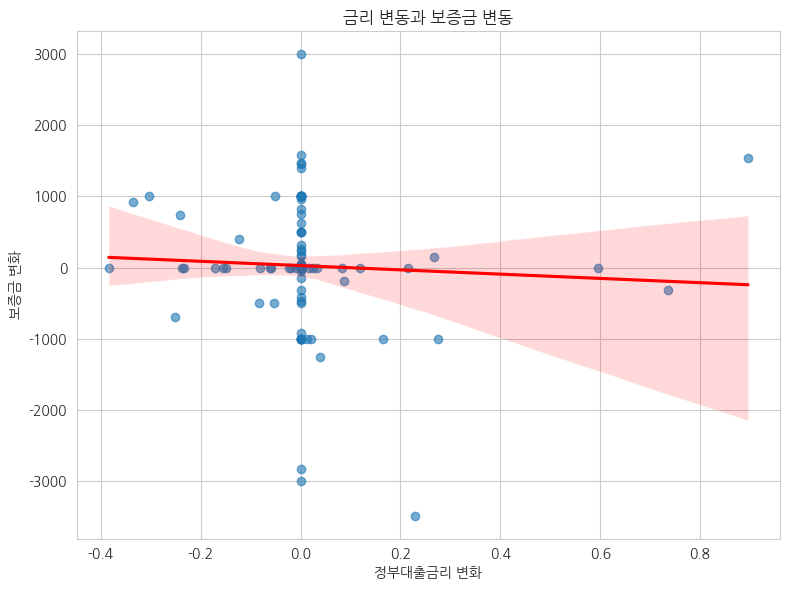

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=eda_monthly,
    x="금리변화",
    y="보증금변화",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"}
)

plt.title("금리 변동과 보증금 변동")
plt.xlabel("정부대출금리 변화")
plt.ylabel("보증금 변화")

plt.tight_layout()
plt.show()

## 4-1. 가설 검정 - H1

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

reg_df = monthly_stats.copy()

# 금리, 월세, 보증금의 전월 대비 변화
reg_df["금리변화"] = reg_df["정부대출금금리"].diff()

reg_df["월세변화"] = (
    reg_df["제곱미터당월세_중앙값"].diff()
)

reg_df["보증금변화"] = (
    reg_df["보증금_중앙값"].diff()
)

# 시간 추세
reg_df["시간추세"] = np.arange(len(reg_df))

# 결측치 제거
reg_df = reg_df.dropna(
    subset=[
        "금리변화",
        "월세변화",
        "보증금변화"
    ]
).copy()

print(f"회귀분석 관측치: {len(reg_df):,}개월")

회귀분석 관측치: 119개월


In [ ]:
X = reg_df[["금리변화"]]
X = sm.add_constant(X)

y = reg_df["월세변화"]

model1 = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   월세변화   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     5.254
Date:                Wed, 12 Aug 2026   Prob (F-statistic):             0.0237
Time:                        03:32:07   Log-Likelihood:                 72.971
No. Observations:                 119   AIC:                            -141.9
Df Residuals:                     117   BIC:                            -136.4
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.007      0.151      0.8

In [ ]:
X = reg_df[
    [
        "금리변화",
        "시간추세"
    ]
]

X = sm.add_constant(X)

y = reg_df["월세변화"]

model2 = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   월세변화   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     2.644
Date:                Wed, 12 Aug 2026   Prob (F-statistic):             0.0754
Time:                        03:32:27   Log-Likelihood:                 72.989
No. Observations:                 119   AIC:                            -140.0
Df Residuals:                     116   BIC:                            -131.6
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0051      0.013      0.391      0.6

In [ ]:
X = reg_df[
    [
        "금리변화",
        "시간추세"
    ]
]

X = sm.add_constant(X)

y = reg_df["보증금변화"]

model3 = sm.OLS(y, X).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": 3}
)

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  보증금변화   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.012
Method:                 Least Squares   F-statistic:                    0.4111
Date:                Wed, 12 Aug 2026   Prob (F-statistic):              0.664
Time:                        03:32:32   Log-Likelihood:                -967.59
No. Observations:                 119   AIC:                             1941.
Df Residuals:                     116   BIC:                             1950.
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -44.7879     75.706     -0.592      0.5

In [ ]:
result = pd.DataFrame({
    "모형": [
        "모형1: 월세",
        "모형2: 월세 + 시간추세",
        "모형3: 보증금 + 시간추세"
    ],
    "금리변화_계수": [
        model1.params["금리변화"],
        model2.params["금리변화"],
        model3.params["금리변화"]
    ],
    "p값": [
        model1.pvalues["금리변화"],
        model2.pvalues["금리변화"],
        model3.pvalues["금리변화"]
    ]
})

display(
    result.style
    .format({
        "금리변화_계수": "{:.4f}",
        "p값": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#E9EFF7"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px 20px")
            ]
        }
    ])
)

,모형,금리변화_계수,p값
0,모형1: 월세,0.1920,0.0219
1,모형2: 월세 + 시간추세,0.1923,0.0218
2,모형3: 보증금 + 시간추세,-306.0882,0.6550


## 4-2. 가설 검정 - H2

In [16]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf


# ============================================================
# 1. 분석 데이터 구성
# ============================================================

h2_df = df.copy()

# 계약일 → 년월
h2_df["년월"] = (
    h2_df["계약일"].astype(str).str[:4]
    + "-"
    + h2_df["계약일"].astype(str).str[4:6]
)


# ============================================================
# 2. 자치구별 월별 데이터 집계
# ============================================================

h2_monthly = (
    h2_df
    .groupby(["자치구명", "년월"])
    .agg(
        거래건수=("임대료(만원)", "size"),

        # 월세
        월세_평균=("임대료(만원)", "mean"),
        월세_중앙값=("임대료(만원)", "median"),

        # 단위면적당 월세
        제곱미터당월세_평균=("월세_㎡당", "mean"),
        제곱미터당월세_중앙값=("월세_㎡당", "median"),

        # 보증금
        보증금_평균=("보증금(만원)", "mean"),
        보증금_중앙값=("보증금(만원)", "median"),

        # 금리
        정부대출금금리=("정부대출금금리", "first")
    )
    .reset_index()
)


# ============================================================
# 3. 자치구별 전월 대비 변화량
# ============================================================

h2_monthly = (
    h2_monthly
    .sort_values(["자치구명", "년월"])
    .copy()
)

h2_monthly["금리변화"] = (
    h2_monthly
    .groupby("자치구명")["정부대출금금리"]
    .diff()
)

h2_monthly["월세변화"] = (
    h2_monthly
    .groupby("자치구명")["제곱미터당월세_중앙값"]
    .diff()
)


# ============================================================
# 4. 시간 추세 변수
# ============================================================

# 전체 월 순서
month_order = sorted(
    h2_monthly["년월"].unique()
)

month_index = {
    month: i
    for i, month in enumerate(month_order)
}

h2_monthly["시간추세"] = (
    h2_monthly["년월"].map(month_index)
)


# ============================================================
# 5. 결측치 제거
# ============================================================

h2_reg = (
    h2_monthly
    .dropna(
        subset=[
            "금리변화",
            "월세변화",
            "시간추세",
            "자치구명"
        ]
    )
    .copy()
)


# ============================================================
# 6. 분석 데이터 확인
# ============================================================

print("=" * 50)
print("H2 분석 데이터")
print("=" * 50)

print(f"관측치: {len(h2_reg):,}건")
print(f"자치구: {h2_reg['자치구명'].nunique():,}개")
print(f"월: {h2_reg['년월'].nunique():,}개월")


# ============================================================
# 7. H2 회귀모형
# ============================================================
#
# 월세변화
#   = 금리변화
#   + 자치구
#   + 금리변화 × 자치구
#   + 시간추세
#
# C(자치구명) : 자치구 범주형 변수
# 금리변화:C(자치구명) : 자치구별 금리 효과 차이
#
# ============================================================

model_h2 = smf.ols(
    formula="""
        월세변화
        ~ 금리변화
        + C(자치구명)
        + 금리변화:C(자치구명)
        + 시간추세
    """,
    data=h2_reg
).fit(
    cov_type="HAC",
    cov_kwds={
        "maxlags": 3
    }
)


# ============================================================
# 8. 회귀분석 전체 결과
# ============================================================

print("\n")
print("=" * 50)
print("H2 회귀분석 결과")
print("=" * 50)

print(model_h2.summary())


# ============================================================
# 9. 기준 자치구 확인
# ============================================================

districts = sorted(
    h2_reg["자치구명"].dropna().unique()
)

reference_district = districts[0]

base_coef = model_h2.params["금리변화"]


# ============================================================
# 10. 자치구별 실제 금리 효과 계산
# ============================================================

district_results = []

for district in districts:

    # 기준 자치구
    if district == reference_district:

        coef = base_coef

        # 기준 자치구의 금리변화 계수 p값
        p_value = model_h2.pvalues["금리변화"]

    # 나머지 자치구
    else:

        interaction_term = (
            f"금리변화:C(자치구명)[T.{district}]"
        )

        interaction_coef = (
            model_h2.params[interaction_term]
        )

        # 실제 자치구 금리 효과
        coef = (
            base_coef
            + interaction_coef
        )

        # 기준 자치구와의 효과 차이에 대한 p값
        p_value = (
            model_h2.pvalues[interaction_term]
        )

    district_results.append({
        "자치구": district,
        "금리변화_계수": coef,
        "p값": p_value
    })


h2_district_result = pd.DataFrame(
    district_results
)


# 금리 효과가 큰 순서
h2_district_result = (
    h2_district_result
    .sort_values(
        "금리변화_계수",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# 11. 전체 상호작용항 추출
# ============================================================

interaction_terms = [
    term
    for term in model_h2.params.index
    if "금리변화:C(자치구명)" in term
]


# ============================================================
# 12. Wald Test
# ============================================================
#
# H0:
# 모든 자치구의 금리 효과가 동일하다.
#
# H1:
# 적어도 일부 자치구의 금리 효과가 다르다.
#
# ============================================================

n_params = len(model_h2.params)

R = np.zeros(
    (
        len(interaction_terms),
        n_params
    )
)


for i, term in enumerate(interaction_terms):

    param_index = (
        model_h2.params.index.get_loc(term)
    )

    R[i, param_index] = 1


wald_result = model_h2.wald_test(R)

h2_wald_p = float(
    np.asarray(
        wald_result.pvalue
    ).ravel()[0]
)


# ============================================================
# 13. H2 최종 검증 결과
# ============================================================

h2_final_result = pd.DataFrame({
    "모형": [
        "H2: 월세 + 자치구 상호작용"
    ],

    "검정방법": [
        "금리변화 × 자치구 Wald Test"
    ],

    "Wald p값": [
        h2_wald_p
    ],

    "유의성(5%)": [
        "유의" if h2_wald_p < 0.05 else "비유의"
    ],

    "판정": [
        "채택" if h2_wald_p < 0.05 else "기각"
    ]
})


# ============================================================
# 14. PPT용 H2 최종 결과표
# ============================================================

print("\n")
print("=" * 50)
print("H2 최종 검증 결과")
print("=" * 50)

display(
    h2_final_result.style
    .format({
        "Wald p값": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#E9EFF7"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px 20px")
            ]
        }
    ])
)


# ============================================================
# 15. 자치구별 금리 효과 결과표
# ============================================================

print("\n")
print("=" * 50)
print("자치구별 금리 효과")
print("=" * 50)

display(
    h2_district_result.style
    .format({
        "금리변화_계수": "{:.4f}",
        "p값": "{:.4f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#E9EFF7"),
                ("font-weight", "bold")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("padding", "8px 20px")
            ]
        }
    ])
)

H2 분석 데이터
관측치: 2,975건
자치구: 25개
월: 119개월


H2 회귀분석 결과
                            OLS Regression Results                            
Dep. Variable:                   월세변화   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.471
Date:                Thu, 13 Aug 2026   Prob (F-statistic):             0.0177
Time:                        03:01:17   Log-Likelihood:                 151.89
No. Observations:                2975   AIC:                            -201.8
Df Residuals:                    2924   BIC:                             104.1
Df Model:                          50                                         
Covariance Type:                  HAC                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,모형,검정방법,Wald p값,유의성(5%),판정
0,H2: 월세 + 자치구 상호작용,금리변화 × 자치구 Wald Test,0.0158,유의,채택




자치구별 금리 효과


,자치구,금리변화_계수,p값
0,중랑구,0.4971,0.0766
1,동대문구,0.4605,0.0907
2,은평구,0.3814,0.2012
3,영등포구,0.2803,0.1809
4,구로구,0.2705,0.2547
5,강북구,0.2554,0.4656
6,성북구,0.2260,0.4151
7,중구,0.2221,0.5610
8,금천구,0.2100,0.5971
9,관악구,0.2072,0.6318
